In [1]:
import numpy as np
import pandas as pd
pd.set_option('display.max_columns', None)

import math
from scipy import stats
from statsmodels.stats.outliers_influence import variance_inflation_factor
from collections import Counter

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Preprocessing
from sklearn.preprocessing import MinMaxScaler, StandardScaler, MaxAbsScaler, RobustScaler, PowerTransformer, QuantileTransformer, OrdinalEncoder, LabelEncoder
from sklearn.impute import SimpleImputer

# Model Selection
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.model_selection import KFold, StratifiedKFold, train_test_split, GridSearchCV, RepeatedStratifiedKFold
#import autogluon as ag

# Models
from sklearn.ensemble import HistGradientBoostingClassifier, GradientBoostingClassifier, AdaBoostClassifier,RandomForestClassifier,ExtraTreesClassifier,VotingClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
import optuna
from optuna.integration import LightGBMPruningCallback

import torch
import torch.nn as nn
import torch.optim as optim
if torch.cuda.is_available():
    device = torch.device("cuda")  
else:
    device = torch.device("cpu")   
    
# Metrics 
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.metrics import auc
from sklearn.metrics import roc_auc_score, roc_curve, make_scorer, f1_score

import warnings
warnings.filterwarnings('ignore')

train = pd.read_csv('/kaggle/input/playground-series-s3e24/train.csv')
test = pd.read_csv('/kaggle/input/playground-series-s3e24/test.csv')
sample_submission = pd.read_csv('/kaggle/input/playground-series-s3e24/sample_submission.csv',index_col='id')
# origin = pd.read_csv('/kaggle/input/software-defect-prediction/jm1.csv')

# train["is_generated"] = 1
# test["is_generated"] = 1
# origin["is_generated"] = 0

# Drop column id
train.drop('id',axis=1,inplace=True)
test.drop('id',axis=1,inplace=True)

# train_total = pd.concat([train, origin], ignore_index=True)
# train_total.drop_duplicates(inplace=True)

# total = pd.concat([train_total, test], ignore_index=True)


print('The shape of the train data:', train.shape)
print('The shape of the test data:', test.shape)
# print('The shape of the total data:', total.shape)

The shape of the train data: (159256, 23)
The shape of the test data: (106171, 22)


In [5]:
train.head()

,age,height(cm),weight(kg),waist(cm),eyesight(left),eyesight(right),hearing(left),hearing(right),systolic,relaxation,fasting blood sugar,Cholesterol,triglyceride,HDL,LDL,hemoglobin,Urine protein,serum creatinine,AST,ALT,Gtp,dental caries,smoking
0,55,165,60,81.0,0.5,0.6,1,1,135,87,94,172,300,40,75,16.5,1,1.0,22,25,27,0,1
1,70,165,65,89.0,0.6,0.7,2,2,146,83,147,194,55,57,126,16.2,1,1.1,27,23,37,1,0
2,20,170,75,81.0,0.4,0.5,1,1,118,75,79,178,197,45,93,17.4,1,0.8,27,31,53,0,1
3,35,180,95,105.0,1.5,1.2,1,1,131,88,91,180,203,38,102,15.9,1,1.0,20,27,30,1,0
4,30,165,60,80.5,1.5,1.0,1,1,121,76,91,155,87,44,93,15.4,1,0.8,19,13,17,0,1


In [6]:
train.describe().T\
    .style.bar(subset=['mean'], color=px.colors.qualitative.G10[2])\
    .background_gradient(subset=['std'], cmap='Blues')\
    .background_gradient(subset=['50%'], cmap='BuGn')

,count,mean,std,min,25%,50%,75%,max
age,159256.000000,44.306626,11.842286,20.000000,40.000000,40.000000,55.000000,85.000000
height(cm),159256.000000,165.266929,8.818970,135.000000,160.000000,165.000000,170.000000,190.000000
weight(kg),159256.000000,67.143662,12.586198,30.000000,60.000000,65.000000,75.000000,130.000000
waist(cm),159256.000000,83.001990,8.957937,51.000000,77.000000,83.000000,89.000000,127.000000
eyesight(left),159256.000000,1.005798,0.402113,0.100000,0.800000,1.000000,1.200000,9.900000
eyesight(right),159256.000000,1.000989,0.392299,0.100000,0.800000,1.000000,1.200000,9.900000
hearing(left),159256.000000,1.023974,0.152969,1.000000,1.000000,1.000000,1.000000,2.000000
hearing(right),159256.000000,1.023421,0.151238,1.000000,1.000000,1.000000,1.000000,2.000000
systolic,159256.000000,122.503648,12.729315,77.000000,114.000000,121.000000,130.000000,213.000000
relaxation,159256.000000,76.874071,8.994642,44.000000,70.000000,78.000000,82.000000,133.000000


In [7]:
def summary(df):
    sum = pd.DataFrame(df.dtypes, columns=['dtypes'])
    sum['missing#'] = df.isna().sum()
    sum['missing%'] = (df.isna().sum())/len(df)
    sum['uniques'] = df.nunique().values
    sum['count'] = df.count().values
    #sum['skew'] = df.skew().values
    return sum

In [8]:
summary(test).style.background_gradient(cmap='Blues')

,dtypes,missing#,missing%,uniques,count
age,int64,0,0.000000,18,106171
height(cm),int64,0,0.000000,16,106171
weight(kg),int64,0,0.000000,26,106171
waist(cm),float64,0,0.000000,508,106171
eyesight(left),float64,0,0.000000,20,106171
eyesight(right),float64,0,0.000000,18,106171
hearing(left),int64,0,0.000000,2,106171
hearing(right),int64,0,0.000000,2,106171
systolic,int64,0,0.000000,114,106171
relaxation,int64,0,0.000000,78,106171


In [26]:
train.nunique()

id                     159256
age                        18
height(cm)                 14
weight(kg)                 28
waist(cm)                 531
eyesight(left)             20
eyesight(right)            17
hearing(left)               2
hearing(right)              2
systolic                  112
relaxation                 75
fasting blood sugar       229
Cholesterol               227
triglyceride              392
HDL                       108
LDL                       222
hemoglobin                134
Urine protein               6
serum creatinine           28
AST                       140
ALT                       188
Gtp                       362
dental caries               2
smoking                     2
dtype: int64

In [2]:
conts = ['age', 'height(cm)', 'weight(kg)', 'waist(cm)', 'eyesight(left)',
       'eyesight(right)', 'systolic',
       'relaxation', 'fasting blood sugar', 'Cholesterol', 'triglyceride',
       'HDL', 'LDL', 'hemoglobin',  'serum creatinine', 'AST',
       'ALT', 'Gtp']

cats = ['dental caries','Urine protein','hearing(left)', 'hearing(right)']

cols = conts+cats

target = 'smoking'

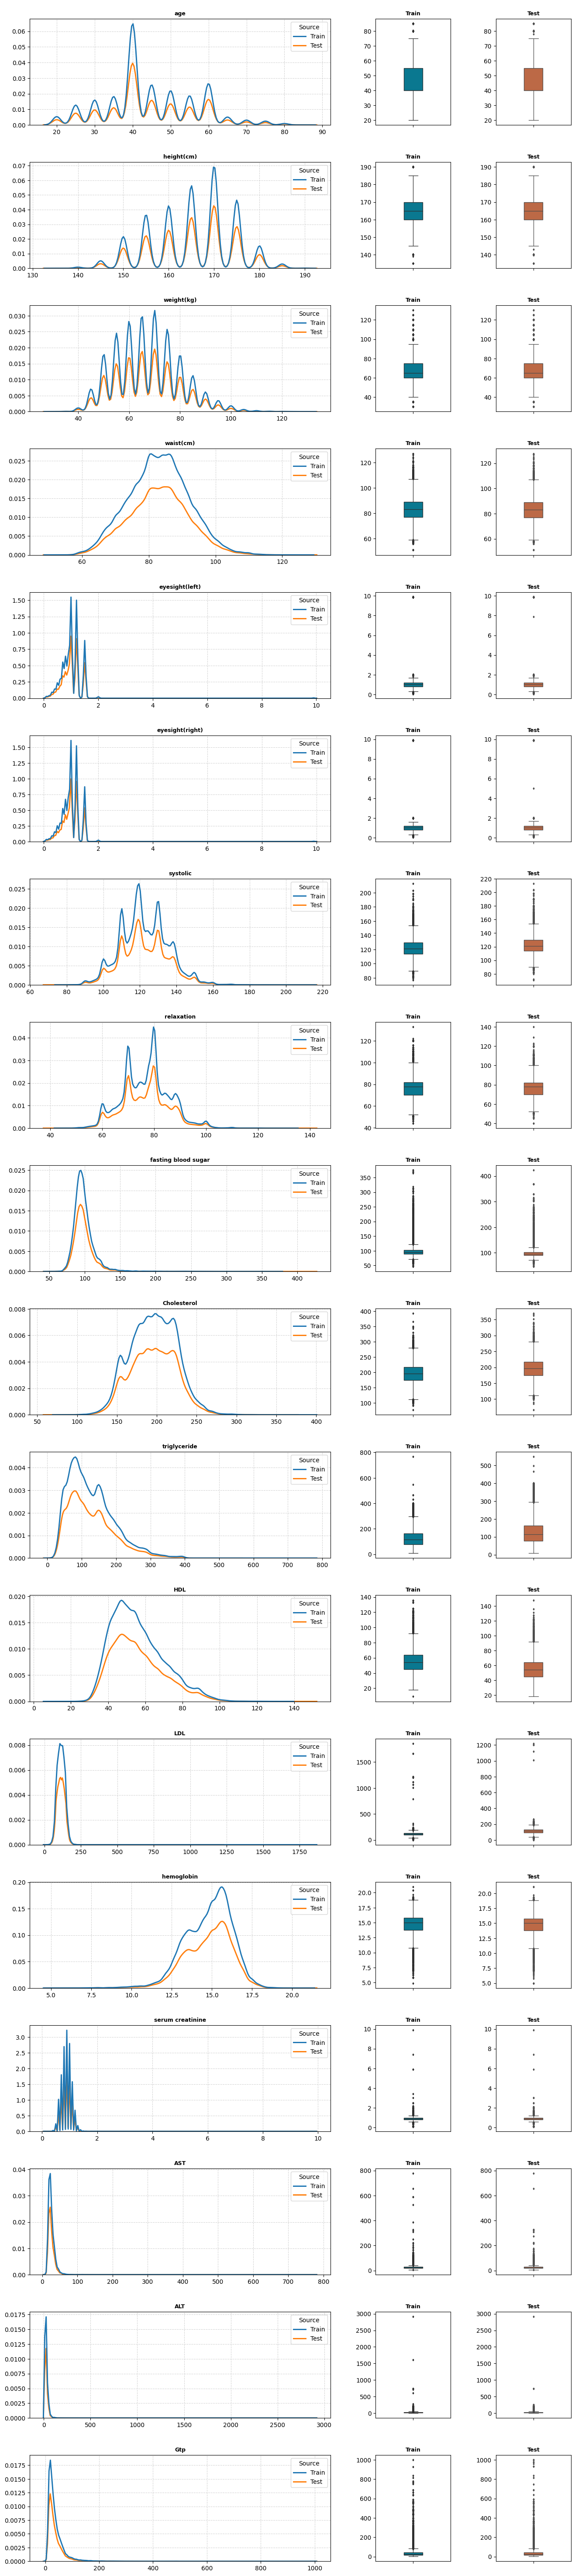

In [12]:
df = pd.concat([train[conts].assign(Source = 'Train'), 
                test[conts].assign(Source = 'Test')], 
               axis=0, ignore_index = True);

fig, axes = plt.subplots(len(conts), 3 ,figsize = (16, len(conts) * 4.2), 
                         gridspec_kw = {'hspace': 0.35, 'wspace': 0.3, 'width_ratios': [0.80, 0.20, 0.20]});

for i,col in enumerate(conts):
    ax = axes[i,0];
    sns.kdeplot(data = df[[col, 'Source']], x = col, hue = 'Source', ax = ax, linewidth = 2.1)
    ax.set_title(f"\n{col}",fontsize = 9, fontweight= 'bold');
    ax.grid(visible=True, which = 'both', linestyle = '--', color='lightgrey', linewidth = 0.75);
    ax.set(xlabel = '', ylabel = '');
    ax = axes[i,1];
    sns.boxplot(data = df.loc[df.Source == 'Train', [col]], y = col, width = 0.25,saturation = 0.90, linewidth = 0.90, fliersize= 2.25, color = '#037d97',
                ax = ax);
    ax.set(xlabel = '', ylabel = '');
    ax.set_title(f"Train",fontsize = 9, fontweight= 'bold');

    ax = axes[i,2];
    sns.boxplot(data = df.loc[df.Source == 'Test', [col]], y = col, width = 0.25, fliersize= 2.25,
                saturation = 0.6, linewidth = 0.90, color = '#E4591E',
                ax = ax); 
    ax.set(xlabel = '', ylabel = '');
    ax.set_title(f"Test",fontsize = 9, fontweight= 'bold');

plt.tight_layout()

In [25]:
def chi_squared_test(df, input_var, target_var, significance_level=0.05):
    contingency_table = pd.crosstab(df[input_var], df[target_var])
    chi2, p, _, _ = stats.chi2_contingency(contingency_table)
    
    if p < significance_level:
        print(f'\033[32m{input_var} has a significant relationship with the target variable.\033[0m') 
    else:
        print(f'\033[31m{input_var} does not have a significant relationship with the target variable.\033[0m')  

In [26]:
for i in cats:
    chi_squared_test(train, i, target)

dental caries has a significant relationship with the target variable.
Urine protein has a significant relationship with the target variable.
hearing(left) has a significant relationship with the target variable.
hearing(right) has a significant relationship with the target variable.


In [28]:
def plot_count(df,columns,n_cols,hue):
    '''
    # Function to genear countplot
    df: total data
    columns: category variables
    n_cols: num of cols
    '''
    n_rows = (len(columns) - 1) // n_cols + 1
    fig, ax = plt.subplots(n_rows, n_cols, figsize=(17, 4 * n_rows))
    ax = ax.flatten()
    
    for i, column in enumerate(columns):
        sns.countplot(data=df, x=column, ax=ax[i],hue=hue)

        # Titles
        ax[i].set_title(f'{column} Counts', fontsize=18)
        ax[i].set_xlabel(None, fontsize=16)
        ax[i].set_ylabel(None, fontsize=16)
        ax[i].tick_params(axis='x', rotation=10)

        for p in ax[i].patches:
            value = int(p.get_height())
            ax[i].annotate(f'{value:.0f}', (p.get_x() + p.get_width() / 2, p.get_height()),
                           ha='center', va='bottom', fontsize=9)

    ylim_top = ax[i].get_ylim()[1]
    ax[i].set_ylim(top=ylim_top * 1.1)
    for i in range(len(columns), len(ax)):
        ax[i].axis('off')

    # fig.suptitle(plotname, fontsize=25, fontweight='bold')
    plt.tight_layout()
    plt.show()

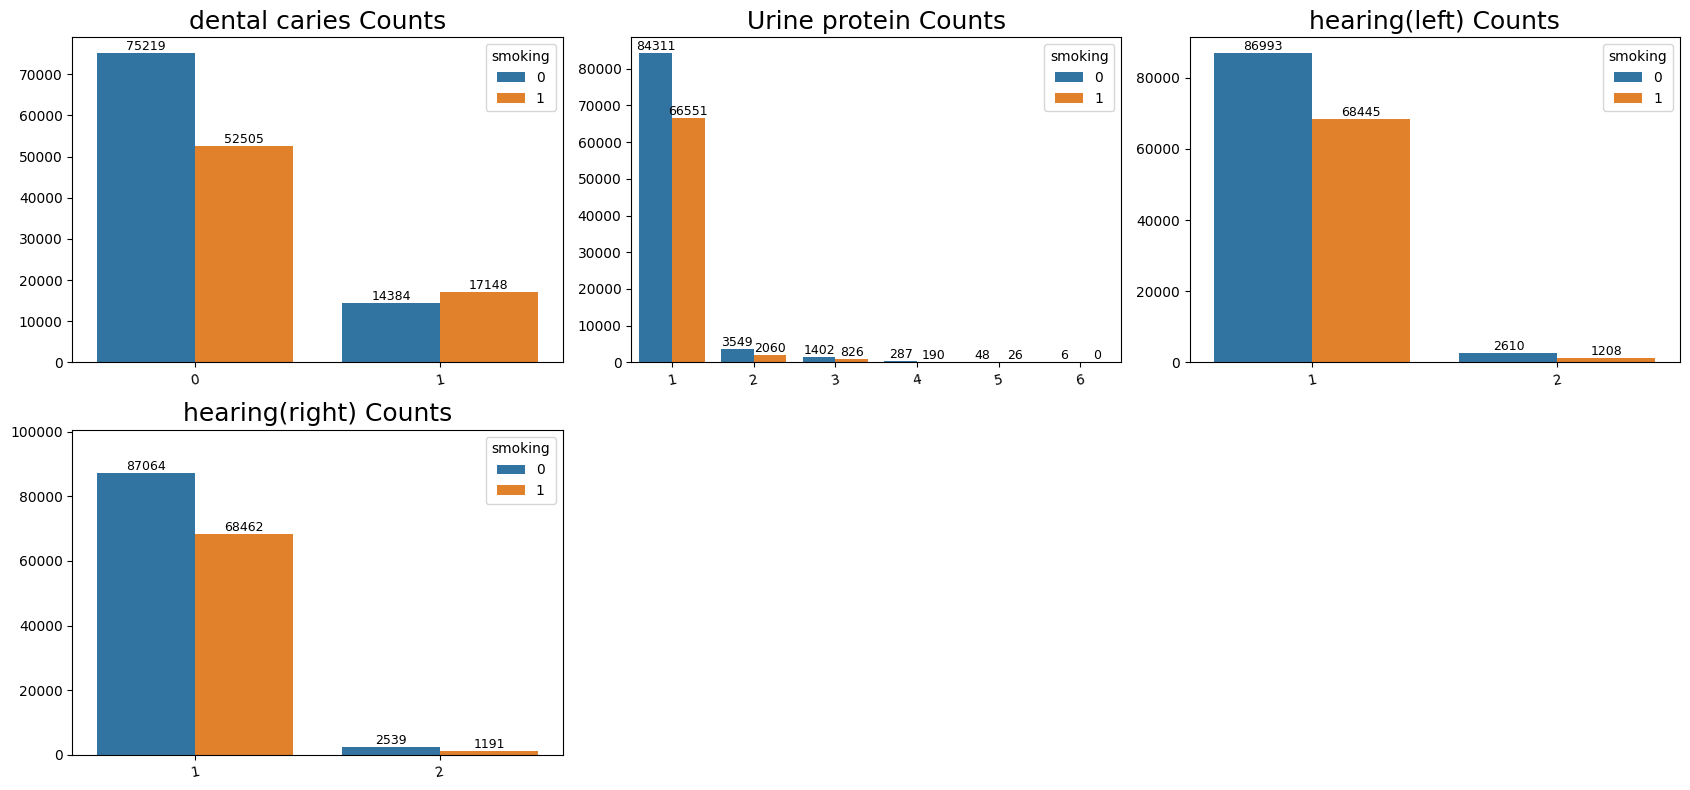

In [29]:
plot_count(train,cats,3,'smoking')

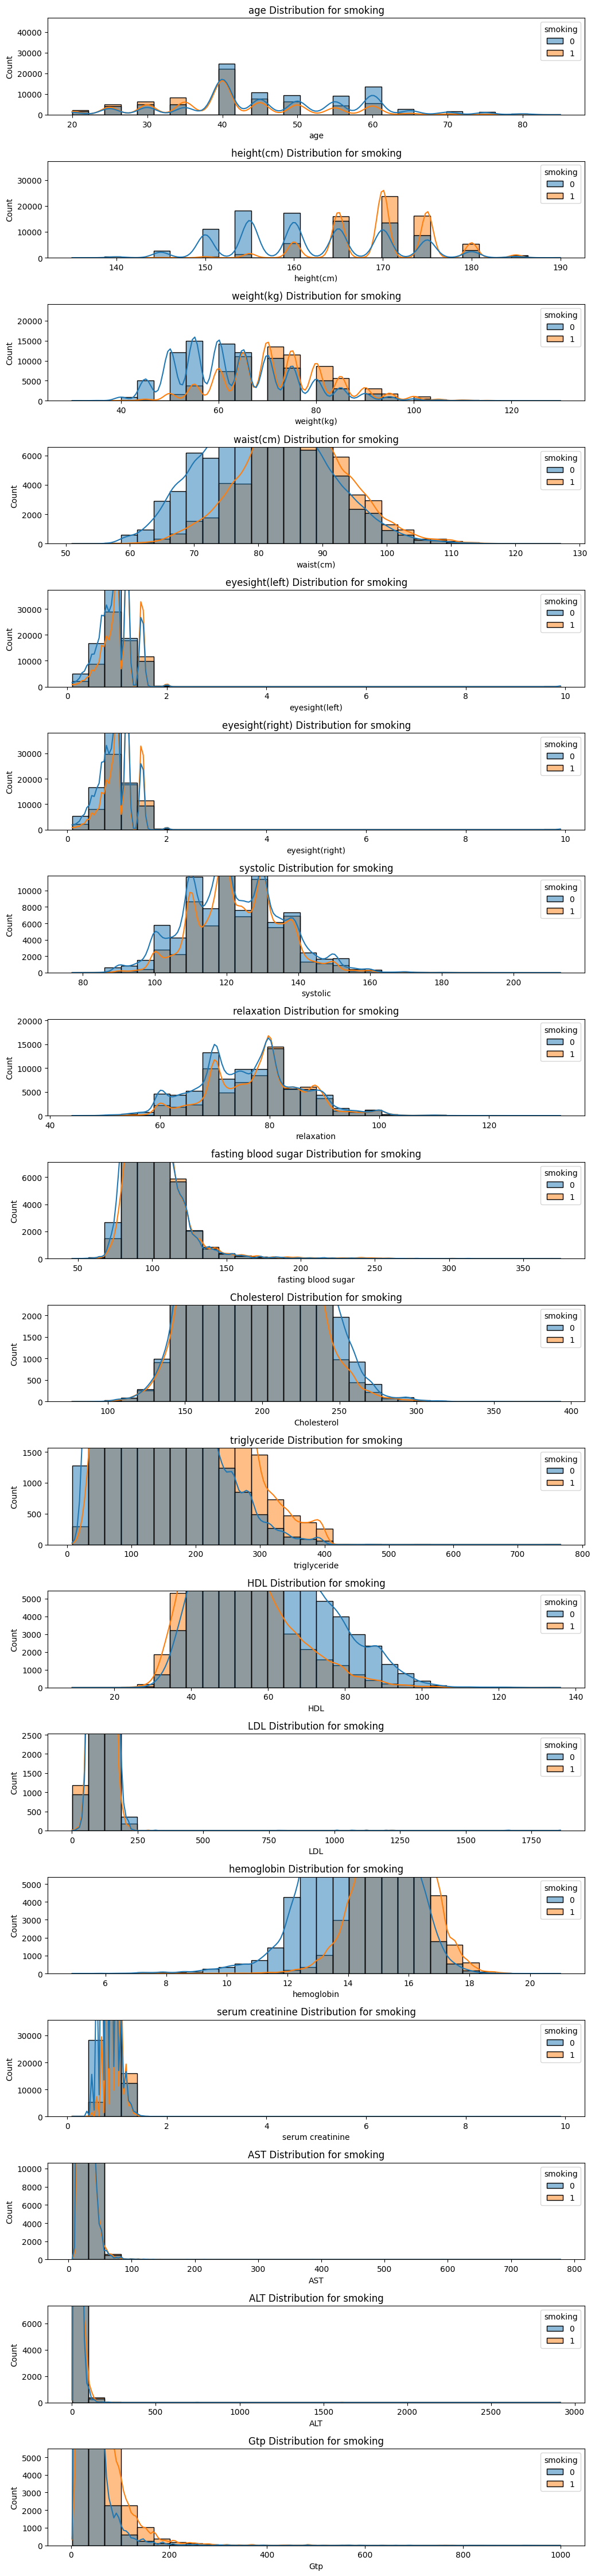

In [33]:
plt.figure(figsize=(14, len(conts) * 2.5))

for idx, column in enumerate(conts):
    plt.subplot(len(conts), 2, idx*2+1)
    sns.histplot(x=column, hue="smoking", data=train, bins=30, kde=True)
    plt.title(f"{column} Distribution for smoking")
    plt.ylim(0, train[column].value_counts().max() + 10)
    
plt.tight_layout()
plt.show()

In [3]:
learningMetadata = {}

In [4]:
# Metrics
def auc_score(y_true, y_pred):
    return roc_auc_score(y_true, y_pred)

In [21]:
def learner(df_train,df_test, model, selected_features, note):
    skf = StratifiedKFold(shuffle=True, random_state=1)
    auc_accu_stratified = []
    model_preds_test = []
    model_preds_oof = []
    oof_y = []
    
    X_train = df_train[selected_features]
    Y_train = df_train[target]
    X_test = df_test[selected_features]
    
    for i,(train_index, test_index) in enumerate(skf.split(X_train, Y_train)):
        print('---------------------------------------------------------------')
        x_train_fold, x_test_fold = X_train.iloc[train_index], X_train.iloc[test_index]
        y_train_fold, y_test_fold = Y_train[train_index], Y_train[test_index]
       
        model.fit(x_train_fold, y_train_fold)
        model_oof_preds = model.predict_proba(x_test_fold)[:,1]
        aucScore = auc_score(y_test_fold,model_oof_preds)
        

        model_preds_test.append(model.predict_proba(X_test))
        model_preds_oof.append(model_oof_preds)
        oof_y.append(y_test_fold)

        print(f"Fold, {i+1}, ==> {note} oof AUC score is ==> {aucScore}")
        auc_accu_stratified.append(aucScore)
    
    print('---------------------------------------------------------------')
    avgAcc = np.array(auc_accu_stratified).mean()
    print('Average Accuracy of model is:', avgAcc)
    learningMetadata[note] = {
#         'cols': selected_features,
        'avgAcc': avgAcc
    }
    print('-------------------------------------------------------------')
    print(pd.DataFrame.from_dict(learningMetadata).T)
    return model,model_preds_test,model_preds_oof,oof_y

In [6]:
def subm(preds, file):
    sample_submission['smoking'] = preds
    sample_submission.to_csv('sub-'+file+'.csv')

In [30]:
rf,preds,acc = learner(train,test,RandomForestClassifier(),cols,'BasicRF-Allcols')

---------------------------------------------------------------
Fold, 1, ==> BasicRF-Allcols oof F1 score is ==> 0.8550715816609054
---------------------------------------------------------------
Fold, 2, ==> BasicRF-Allcols oof F1 score is ==> 0.8577475353656286
---------------------------------------------------------------
Fold, 3, ==> BasicRF-Allcols oof F1 score is ==> 0.8582236763045161
---------------------------------------------------------------
Fold, 4, ==> BasicRF-Allcols oof F1 score is ==> 0.8568286540997734
---------------------------------------------------------------
Fold, 5, ==> BasicRF-Allcols oof F1 score is ==> 0.8554450150583123
---------------------------------------------------------------
Average Accuracy of model is: 0.8566632924978272
                   avgAcc
BasicRF-Allcols  0.856663


In [53]:
subm(np.mean(preds,axis=0)[:,1],'BasicRF-Allcols')

In [8]:
nfolds = 5
skfold = StratifiedKFold(n_splits=nfolds,shuffle=True,random_state=0)

X=train[cols]
y=train[target]

In [12]:
def rf_objective(trial):

        # Set the hyperparameters of the XGBoost classifier.
        params = { 
            'n_estimators' : trial.suggest_int("n_estimators", 100, 500, 25),
            'max_depth' : trial.suggest_int("max_depth", 2, 15),
            'min_samples_split' : trial.suggest_int("min_samples_split", 20, 1000),
            'min_samples_leaf' : trial.suggest_int("min_samples_leaf", 20, 1000),
            'max_features':trial.suggest_float('max_features',0.01,1),
            'n_jobs':-1
            }
        
        rf_auc_score_avg = 0
        for idx, (train_idx,val_idx) in enumerate(skfold.split(X,y)):
            train_X = X.iloc[train_idx]
            val_X = X.iloc[val_idx]
            train_y = y[train_idx]
            val_y = y[val_idx]

            rf_model = RandomForestClassifier(**params)

            rf_model.fit(train_X,train_y)

            rf_prediction = rf_model.predict_proba(val_X)[:,1]
            rf_auc_score = auc_score(val_y, rf_prediction)
#             print(f'The AUC score evaluated on the validation subset using XGB model for fold {idx}: ', xgb_auc_score)

            rf_auc_score_avg += rf_auc_score
            
        rf_auc_score_avg /=nfolds
#         print(f'The averaged AUC score evaluated on the validation subset using XGB model:', rf_auc_score_avg)
        return -rf_auc_score_avg

In [ ]:
rf_study = optuna.create_study()
rf_study.optimize(rf_objective, n_trials=50,show_progress_bar=True)
best_rf_params = rf_study.best_trial.params
print('Best RF hyper parameters:', best_rf_params)

There are some categorical variables and continous and skewed variables. check the relationship of the variables with the prediction variable. 
Also, check feature importance on random forest. 

In [57]:
def rf_feat_importance(m, df):
    return pd.DataFrame({'cols':df.columns, 'imp':m.feature_importances_}
                       ).sort_values('imp', ascending=False)

def plot_fi(fi):
    return fi.plot('cols', 'imp', 'barh', figsize=(12,7), legend=False)

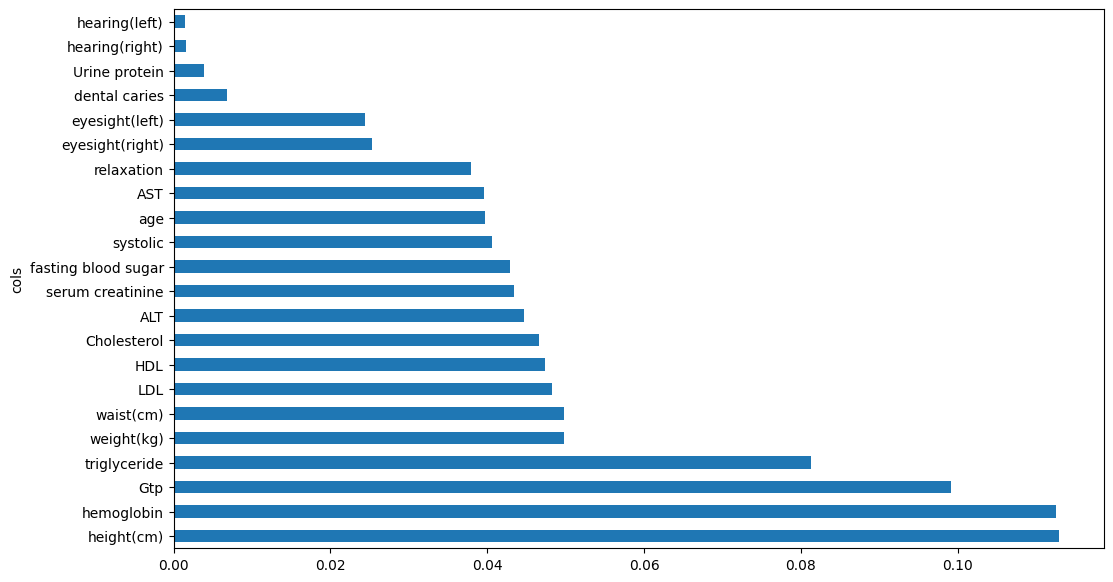

In [58]:
fi = rf_feat_importance(rf, train[cols])
plot_fi(fi[:30]);

In [59]:
to_keep = fi[fi.imp>0.02].cols

In [60]:
rf,preds,acc = learner(train,test,RandomForestClassifier(),to_keep,'BasicRF-ImpCols')

---------------------------------------------------------------
Fold, 1, ==> BasicRF-ImpCols oof F1 score is ==> 0.8541186759933713
---------------------------------------------------------------
Fold, 2, ==> BasicRF-ImpCols oof F1 score is ==> 0.8554226823111611
---------------------------------------------------------------
Fold, 3, ==> BasicRF-ImpCols oof F1 score is ==> 0.8576639962455264
---------------------------------------------------------------
Fold, 4, ==> BasicRF-ImpCols oof F1 score is ==> 0.8562466328950388
---------------------------------------------------------------
Fold, 5, ==> BasicRF-ImpCols oof F1 score is ==> 0.8557214716755795
---------------------------------------------------------------
Average Accuracy of model is: 0.8558346918241355
                   avgAcc
BasicRF-Allcols  0.856663
BasicRF-ImpCols  0.855835


In [61]:
subm(np.mean(preds,axis=0)[:,1],'BasicRF-ImpCols')

In [8]:
bestRFParams =  {'n_estimators': 175, 'max_depth': 13, 'min_samples_split': 174, 'min_samples_leaf': 20, 'max_features': 0.5151303250276628}
tunedRF = RandomForestClassifier(**bestRFParams)

In [22]:
rfTuned,predsRF_test,predsRF_oof,oof_y_RF =learner(train,test,tunedRF,cols,'TunedRF-AllCols')

---------------------------------------------------------------
Fold, 1, ==> TunedRF-AllCols oof AUC score is ==> 0.8559692616584474
---------------------------------------------------------------
Fold, 2, ==> TunedRF-AllCols oof AUC score is ==> 0.8569933759946984
---------------------------------------------------------------
Fold, 3, ==> TunedRF-AllCols oof AUC score is ==> 0.8588759323694843
---------------------------------------------------------------
Fold, 4, ==> TunedRF-AllCols oof AUC score is ==> 0.8570118001744353
---------------------------------------------------------------
Fold, 5, ==> TunedRF-AllCols oof AUC score is ==> 0.855731033462529
---------------------------------------------------------------
Average Accuracy of model is: 0.856916280731919
-------------------------------------------------------------
                    avgAcc
TunedRF-AllCols   0.856916
xgbTuned-AllCols  0.870127
lgbTuned-AllCols  0.869983


In [16]:
subm(np.mean(predsRF,axis=0)[:,1],'TunedRF-AllCols')

In [20]:
xgb1,predsXgb,accXgb = learner(train,test,XGBClassifier(),cols,'BasicXGB-AllCols')

---------------------------------------------------------------
Fold, 1, ==> BasicXGB-AllCols oof F1 score is ==> 0.8644386704084388
---------------------------------------------------------------
Fold, 2, ==> BasicXGB-AllCols oof F1 score is ==> 0.8651260525408391
---------------------------------------------------------------
Fold, 3, ==> BasicXGB-AllCols oof F1 score is ==> 0.8674223388614294
---------------------------------------------------------------
Fold, 4, ==> BasicXGB-AllCols oof F1 score is ==> 0.8649388940926143
---------------------------------------------------------------
Fold, 5, ==> BasicXGB-AllCols oof F1 score is ==> 0.8644483888429049
---------------------------------------------------------------
Average Accuracy of model is: 0.8652748689492451
-------------------------------------------------------------
                    avgAcc
BasicXGB-AllCols  0.865275


In [21]:
subm(np.mean(predsXgb,axis=0)[:,1],'BasicXGB-AllCols')

In [23]:
lgb1,predsLGB,accLGB = learner(train,test,LGBMClassifier(),cols,'BasicLGB-AllCols')

---------------------------------------------------------------
Fold, 1, ==> BasicXGB-AllCols oof F1 score is ==> 0.8636795582760316
---------------------------------------------------------------
Fold, 2, ==> BasicXGB-AllCols oof F1 score is ==> 0.8644861601054175
---------------------------------------------------------------
Fold, 3, ==> BasicXGB-AllCols oof F1 score is ==> 0.8676327148407458
---------------------------------------------------------------
Fold, 4, ==> BasicXGB-AllCols oof F1 score is ==> 0.864050601280975
---------------------------------------------------------------
Fold, 5, ==> BasicXGB-AllCols oof F1 score is ==> 0.8644553008091306
---------------------------------------------------------------
Average Accuracy of model is: 0.86486086706246
-------------------------------------------------------------
                    avgAcc
BasicXGB-AllCols  0.864861


In [12]:
def xgb_objective(trial):

        # Set the hyperparameters of the XGBoost classifier.
        params = {'objective':'binary:logistic', 
                  'n_estimators': trial.suggest_int('n_estimators', 20, 1000, 25),
                  'learning_rate':trial.suggest_loguniform('learning_rate',0.01,0.3),
                  'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
                  'max_depth': trial.suggest_int('max_depth', 2, 15),
                  'gamma': trial.suggest_loguniform('gamma', 1e-8, 1.0),
                  'random_state':0,
#                   'subsample': trial.suggest_discrete_uniform('subsample', 0.6, 1.0, 0.05),
                  'subsample': trial.suggest_loguniform('subsample', 0.3, 0.9),
                  'reg_alpha': trial.suggest_float('reg_alpha', 0.01, 1.0),
                  'reg_lambda': trial.suggest_float('reg_lambda', 0.01, 1.0),
                 }
        
        xgb_auc_score_avg = 0
        for idx, (train_idx,val_idx) in enumerate(skfold.split(X,y)):
            train_X = X.iloc[train_idx]
            val_X = X.iloc[val_idx]
            train_y = y[train_idx]
            val_y = y[val_idx]

            xgb_model = XGBClassifier(**params,tree_method='gpu_hist', gpu_id=0, n_jobs=-1)

            xgb_model.fit(train_X,train_y)

            xgb_prediction = xgb_model.predict_proba(val_X)[:,1]
            xgb_auc_score = auc_score(val_y, xgb_prediction)
#             print(f'The AUC score evaluated on the validation subset using XGB model for fold {idx}: ', xgb_auc_score)

            xgb_auc_score_avg += xgb_auc_score
            
        xgb_auc_score_avg /=nfolds
        print(f'The averaged AUC score evaluated on the validation subset using XGB model:', xgb_auc_score_avg)
        return -xgb_auc_score_avg

In [10]:
xgb_study = optuna.create_study()
xgb_study.optimize(xgb_objective, n_trials=100,show_progress_bar=True)
best_xgb_params = xgb_study.best_trial.params

print('Best XGB hyper parameters:', best_xgb_params)

[I 2023-10-26 01:31:55,264] A new study created in memory with name: no-name-57dd5269-4f36-4fa7-9312-93bdd40f07fd


NameError: name 'xgb_objective' is not defined

In [11]:
bestXGBParams = {'n_estimators': 945, 'learning_rate': 0.18003296079996972, 'min_child_weight': 10, 'max_depth': 3, 'gamma': 3.0304517871789932e-05, 'subsample': 0.8695350833303787, 'reg_alpha': 0.36954026028719084, 'reg_lambda': 0.40057713094371794}
xgbTuned = XGBClassifier(**bestXGBParams)

In [24]:
xgbTuned,predsXGB_test,predsXGB_oof,oof_y_XGB = learner(train,test,xgbTuned,cols,'xgbTuned-AllCols')

---------------------------------------------------------------
Fold, 1, ==> xgbTuned-AllCols oof AUC score is ==> 0.8700254373741885
---------------------------------------------------------------
Fold, 2, ==> xgbTuned-AllCols oof AUC score is ==> 0.8698133121981295
---------------------------------------------------------------
Fold, 3, ==> xgbTuned-AllCols oof AUC score is ==> 0.872124555846673
---------------------------------------------------------------
Fold, 4, ==> xgbTuned-AllCols oof AUC score is ==> 0.8692806924448223
---------------------------------------------------------------
Fold, 5, ==> xgbTuned-AllCols oof AUC score is ==> 0.8693890146324181
---------------------------------------------------------------
Average Accuracy of model is: 0.8701266024992462
-------------------------------------------------------------
                    avgAcc
TunedRF-AllCols   0.856916
xgbTuned-AllCols  0.870127
lgbTuned-AllCols  0.869983


In [19]:
subm(np.mean(predsXGB,axis=0)[:,1],'xgbTuned-AllCols')

In [13]:
def lgb_objective(trial):

        # Set the hyperparameters of the XGBoost classifier.
        params = {
        # "device_type": trial.suggest_categorical("device_type", ['gpu']),
            'n_estimators': trial.suggest_int('n_estimators', 20, 1000, 25),
#             "n_estimators": trial.suggest_categorical("n_estimators", [10000]),
            "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3),
            "num_leaves": trial.suggest_int("num_leaves", 10, 300),
            "max_depth": trial.suggest_int("max_depth", 3, 12),
            "verbose":-1,
            "min_child_samples": trial.suggest_int("min_child_samples", 10, 1000),
            "reg_alpha": trial.suggest_float("reg_alpha", 0, 15),
            "reg_lambda": trial.suggest_float("reg_lambda", 0, 15),
            "min_split_gain": trial.suggest_float("min_split_gain", 0, 15),
            "subsample": trial.suggest_float(
                "subsample", 0.2, 0.95, step=0.1
            ),
            "subsample_freq": trial.suggest_categorical("subsample_freq", [1]),
            "colsample_bytree": trial.suggest_float(
                "colsample_bytree", 0.2, 0.95, step=0.1
            ),
            "metric": "auc",
            "boosting_type": "gbdt"
        }
            
        cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=1121218)

        cv_scores = np.empty(5)
        
        for idx, (train_idx,val_idx) in enumerate(cv.split(X,y)):
            train_X = X.iloc[train_idx]
            val_X = X.iloc[val_idx]
            train_y = y[train_idx]
            val_y = y[val_idx]

            lgb_model = LGBMClassifier(objective='binary',**params)

            lgb_model.fit(train_X,
                          train_y,
                          eval_set=[(val_X,val_y)],
                          eval_metric='auc',
                          early_stopping_rounds=100,
                          callbacks=[
                              LightGBMPruningCallback(trial,'auc')
                          ],
                         )

            lgb_prediction = lgb_model.predict_proba(val_X)[:,1]
            cv_scores[idx] = auc_score(val_y, lgb_prediction)

        return np.mean(cv_scores)

In [13]:
lgbstudy = optuna.create_study(direction="maximize", study_name="LGBM Classifier")
lgbstudy.optimize(lgb_objective, n_trials=200,show_progress_bar=True)
best_lgb_params = lgbstudy.best_trial.params

print('Best LGB hyper parameters:', best_lgb_params)

[I 2023-10-26 01:37:25,606] A new study created in memory with name: LGBM Classifier


NameError: name 'lgb_objective' is not defined

In [14]:
bestLGBParams = {'n_estimators': 470, 'learning_rate': 0.2184429339669851, 'num_leaves': 223, 'max_depth': 9, 'min_child_samples': 467, 'reg_alpha': 5.964660409594812, 'reg_lambda': 6.624016030040239, 'min_split_gain': 1.0907128956939591, 'subsample': 0.8, 'subsample_freq': 1, 'colsample_bytree': 0.8}
lgbTuned = LGBMClassifier(objective='binary',**bestLGBParams)

In [25]:
lgbTuned,predsLGB_test,predsLGB_oof,oof_y_LGB = learner(train,test,lgbTuned,cols,'lgbTuned-AllCols')

---------------------------------------------------------------
Fold, 1, ==> lgbTuned-AllCols oof AUC score is ==> 0.8690719028449905
---------------------------------------------------------------
Fold, 2, ==> lgbTuned-AllCols oof AUC score is ==> 0.8703684958455962
---------------------------------------------------------------
Fold, 3, ==> lgbTuned-AllCols oof AUC score is ==> 0.8712320512064563
---------------------------------------------------------------
Fold, 4, ==> lgbTuned-AllCols oof AUC score is ==> 0.8696187498830814
---------------------------------------------------------------
Fold, 5, ==> lgbTuned-AllCols oof AUC score is ==> 0.8696256598464194
---------------------------------------------------------------
Average Accuracy of model is: 0.8699833719253087
-------------------------------------------------------------
                    avgAcc
TunedRF-AllCols   0.856916
xgbTuned-AllCols  0.870127
lgbTuned-AllCols  0.869983


In [20]:
subm(np.mean(predsLGB,axis=0)[:,1],'lgbTuned-AllCols')

In [61]:
def hill_climbing(x, y, x_test):
    
    # Evaluating oof predictions
    scores = {}
    for col in x.columns:
        scores[col] = roc_auc_score(y, x[col])

    # Sorting the model scores
    scores = {k: v for k, v in sorted(scores.items(), key = lambda item: item[1], reverse = True)}

    # Sort oof_df and test_preds
    x = x[list(scores.keys())]
    x_test = x_test[list(scores.keys())]

    STOP = False
    current_best_ensemble = x.iloc[:,0]
    current_best_test_preds = x_test.iloc[:,0]
    MODELS = x.iloc[:,1:]
    weight_range = np.arange(-0.5, 0.51, 0.01) 
    history = [roc_auc_score(y, current_best_ensemble)]
    j = 0

    while not STOP:
        j += 1
        potential_new_best_cv_score = roc_auc_score(y, current_best_ensemble)
        k_best, wgt_best = None, None
        for k in MODELS:
            for wgt in weight_range:
                potential_ensemble = (1 - wgt) * current_best_ensemble + wgt * MODELS[k]
                cv_score = roc_auc_score(y, potential_ensemble)
                if cv_score > potential_new_best_cv_score:
                    potential_new_best_cv_score = cv_score
                    k_best, wgt_best = k, wgt

        if k_best is not None:
            current_best_ensemble = (1 - wgt_best) * current_best_ensemble + wgt_best * MODELS[k_best]
            current_best_test_preds = (1 - wgt_best) * current_best_test_preds + wgt_best * x_test[k_best]
            MODELS.drop(k_best, axis = 1, inplace = True)
            if MODELS.shape[1] == 0:
                STOP = True
            history.append(potential_new_best_cv_score)
        else:
            STOP = True
        
    hill_ens_pred_1 = current_best_ensemble
    hill_ens_pred_2 = current_best_test_preds
    
    return [hill_ens_pred_1, hill_ens_pred_2]

In [66]:
def learnerEnsemble(df_train,df_test,selected_features):
    ens_cv_scores, ens_preds = list(), list()
    hill_ens_cv_scores, hill_ens_preds =  list(), list()
    
    X = df_train[selected_features]
    Y = df_train[target]
    test_cv = df_test[selected_features]

    sk = RepeatedStratifiedKFold(n_splits = 10, n_repeats = 1, random_state = 42)
    for i, (train_idx, test_idx) in enumerate(sk.split(X, Y)):

        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        Y_train, Y_test = Y.iloc[train_idx], Y.iloc[test_idx]
    
        print('----------------------------------------------------------')
    
        ########
        ## RF ##
        ########

        RF_md = RandomForestClassifier(**{'n_estimators': 175, 'max_depth': 13, 'min_samples_split': 174, 'min_samples_leaf': 20, 'max_features': 0.5151303250276628,'n_jobs':-1}).fit(X_train, Y_train)
    
        RF_pred = RF_md.predict_proba(X_test)[:, 1]
        RF_score = roc_auc_score(Y_test, RF_pred)

        print('Fold', i, '==> RF oof ROC-AUC score is ==>', RF_score)

        RF_pred_test = RF_md.predict_proba(test_cv)[:, 1]
    
    #################
    ## Extra Trees ##
    #################

#     ET_md = ExtraTreesClassifier(n_estimators = 500, 
#                                  max_depth = 7,
#                                  min_samples_split = 15,
#                                  min_samples_leaf = 10).fit(X_train, Y_train)

#     ET_pred = ET_md.predict_proba(X_test)[:, 1]
#     ET_score = roc_auc_score(Y_test, ET_pred)

#     print('Fold', i, '==> ET oof ROC-AUC score is ==>', ET_score)

#     ET_pred_test = ET_md.predict_proba(test_cv)[:, 1]

    ##########################
    ## HistGradientBoosting ##
    ##########################

#     hist_md = HistGradientBoostingClassifier(l2_regularization = 0.01,
#                                              early_stopping = False,
#                                              learning_rate = 0.01,
#                                              max_iter = 500,
#                                              max_depth = 5,
#                                              max_bins = 255,
#                                              min_samples_leaf = 15,
#                                              max_leaf_nodes = 10).fit(X_train, Y_train)
    
#     hist_pred = hist_md.predict_proba(X_test)[:, 1]
#     hist_score = roc_auc_score(Y_test, hist_pred)

#     print('Fold', i, '==> Hist oof ROC-AUC score is ==>', hist_score)  

#     hist_pred_test = hist_md.predict_proba(test_cv)[:, 1]

        ##########
        ## LGBM ##
        ##########

        LGBM_md = LGBMClassifier(**{'n_estimators': 470, 'learning_rate': 0.2184429339669851, 'num_leaves': 223, 'max_depth': 9, 'min_child_samples': 467, 'reg_alpha': 5.964660409594812, 'reg_lambda': 6.624016030040239, 'min_split_gain': 1.0907128956939591, 'subsample': 0.8, 'subsample_freq': 1, 'colsample_bytree': 0.8}).fit(X_train, Y_train)

        lgb_pred = LGBM_md.predict_proba(X_test)[:, 1]
        lgb_score = roc_auc_score(Y_test, lgb_pred)

        print('Fold', i, '==> LGBM oof ROC-AUC score is ==>', lgb_score) 

        lgb_pred_test = LGBM_md.predict_proba(test_cv)[:, 1]

        #########
        ## XGB ##
        #########

        XGB_md = XGBClassifier(**{'n_estimators': 945, 'learning_rate': 0.18003296079996972, 'min_child_weight': 10, 'max_depth': 3, 'gamma': 3.0304517871789932e-05, 'subsample': 0.8695350833303787, 'reg_alpha': 0.36954026028719084, 'reg_lambda': 0.40057713094371794}).fit(X_train, Y_train)

        xgb_pred = XGB_md.predict_proba(X_test)[:, 1]
        xgb_score = roc_auc_score(Y_test, xgb_pred)

        print('Fold', i, '==> XGB oof ROC-AUC score is ==>', xgb_score)

        xgb_pred_test = XGB_md.predict_proba(test_cv)[:, 1]

        ##############
        ## CatBoost ##
        ##############

#         Cat_md = CatBoostClassifier(loss_function = 'Logloss',
#                                 iterations = 500,
#                                 learning_rate = 0.01,
#                                 depth = 7,
#                                 random_strength = 0.5,
#                                 bagging_temperature = 0.7,
#                                 border_count = 30,
#                                 l2_leaf_reg = 5,
#                                 verbose = False, 
#                                 task_type = 'CPU').fit(X_train, Y_train)

#         cat_pred = Cat_md.predict_proba(X_test)[:, 1]
#         cat_score = roc_auc_score(Y_test, cat_pred)

#         print('Fold', i, '==> CatBoost oof ROC-AUC score is ==>', cat_score)

#         cat_pred_test = Cat_md.predict_proba(test_cv)[:, 1]    
    
        ##############
        ## Ensemble ##
        ##############
    
#         ens_pred_1 = (RF_pred + ET_pred + hist_pred + lgb_pred + xgb_pred + cat_pred) / 6
#         ens_pred_2 = (RF_pred_test + ET_pred_test + hist_pred_test + lgb_pred_test + xgb_pred_test + cat_pred_test) / 6
        ens_pred_1 = (RF_pred + lgb_pred + xgb_pred) / 3
        ens_pred_2 = (RF_pred_test + lgb_pred_test + xgb_pred_test) / 3
    
        ens_score_fold = roc_auc_score(Y_test, ens_pred_1)
        ens_cv_scores.append(ens_score_fold)
        ens_preds.append(ens_pred_2)
    
        print('Fold', i, '==> Average Ensemble oof ROC-AUC score is ==>', ens_score_fold)
    
        ############################
        ## Hill Climbing Ensemble ##
        ############################
    
        x = pd.DataFrame({'RF': RF_pred,
#                       'ET': ET_pred, 
#                       'Hist': hist_pred, 
                      'LGBM': lgb_pred,
                      'XGB': xgb_pred,
#                       'Cat': cat_pred
                         })
        y = Y_test
        
        x_test = pd.DataFrame({'RF': RF_pred_test,
#                            'ET': ET_pred_test, 
#                            'Hist': hist_pred_test, 
                           'LGBM': lgb_pred_test,
                           'XGB': xgb_pred_test,
#                            'Cat': cat_pred_test
                              })
    
        hill_results = hill_climbing(x, y, x_test)
    
        hill_ens_score_fold = roc_auc_score(y, hill_results[0])
        hill_ens_cv_scores.append(hill_ens_score_fold)
        hill_ens_preds.append(hill_results[1])

        print('Fold', i, '==> Hill Climbing Ensemble oof ROC-AUC score is ==>', hill_ens_score_fold)
    return ens_preds,hill_ens_preds


In [67]:
avg_preds,hill_preds = learnerEnsemble(train,test,cols)

----------------------------------------------------------
Fold 0 ==> RF oof ROC-AUC score is ==> 0.8560706691429804
Fold 0 ==> LGBM oof ROC-AUC score is ==> 0.8655190324945654
Fold 0 ==> XGB oof ROC-AUC score is ==> 0.8664681818706164
Fold 0 ==> Average Ensemble oof ROC-AUC score is ==> 0.8674995706185143
Fold 0 ==> Hill Climbing Ensemble oof ROC-AUC score is ==> 0.8679288239305196
----------------------------------------------------------
Fold 1 ==> RF oof ROC-AUC score is ==> 0.857193870226816
Fold 1 ==> LGBM oof ROC-AUC score is ==> 0.8709003360711209
Fold 1 ==> XGB oof ROC-AUC score is ==> 0.870708588398753
Fold 1 ==> Average Ensemble oof ROC-AUC score is ==> 0.8713471331415856
Fold 1 ==> Hill Climbing Ensemble oof ROC-AUC score is ==> 0.872591874820557
----------------------------------------------------------
Fold 2 ==> RF oof ROC-AUC score is ==> 0.8613216842777164
Fold 2 ==> LGBM oof ROC-AUC score is ==> 0.8766198736977565
Fold 2 ==> XGB oof ROC-AUC score is ==> 0.875076944200

In [74]:
subm(np.mean(avg_preds,axis=0),'ensemble-AllCols_avg')
subm(np.mean(hill_preds,axis=0),'ensemble-AllCols_hill')